# Paper Analysis: Recalibrating Global River Plastic Emissions

This notebook produces all figures, tables, and results for the paper
"Global river plastic emission models overestimate top emitters:
Implications for intervention effectiveness".

## Structure
1. Data loading and preprocessing
2. Calibration (Section 3.1)
3. Independent confirmation (Section 3.2)
4. Episodic transport analysis (Section 3.3)
5. Tidal retention context (Section 3.4)
6. Recalibrated global estimates (Section 3.5)
7. Capture rate implications (Section 3.6)
8. Sensitivity analyses
9. Export tables and figures

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

RESULTS = Path('../results/figures')
RESULTS.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

In [2]:
obs = pd.read_csv('../data/processed/observed_flux_matched_S3.csv')
fm = pd.read_csv('../data/processed/feature_matrix_v1.csv')
ranking = pd.read_csv('../data/processed/final_ranking_all_rivers.csv')

print(f'Observed flux: {len(obs)} rivers')
print(f'Feature matrix: {fm.shape}')
print(f'Ranking: {len(ranking)} rivers')

# Key variables
log_meijer = np.log10(obs['outfall_ME'])
log_obs = np.log10(obs['obs_annual'])

print(f'\nlog10(Meijer) range: [{log_meijer.min():.2f}, {log_meijer.max():.2f}]')
print(f'log10(Observed) range: [{log_obs.min():.2f}, {log_obs.max():.2f}]')
print(f'\nCountries: {obs["country"].value_counts().to_dict()}')

Observed flux: 66 rivers
Feature matrix: (31819, 42)
Ranking: 31819 rivers

log10(Meijer) range: [0.56, 4.80]
log10(Observed) range: [0.03, 4.23]

Countries: {'JPN': 39, 'THA': 6, 'DEU': 3, 'VNM': 3, 'PHL': 3, 'MYS': 2, 'FRA': 2, 'IDN': 2, 'ESP': 2, 'GTM': 1, 'USA': 1, 'ITA': 1, 'NLD': 1}


## 2. Calibration (Section 3.1)

In [3]:
# Linear regression in log space
slope, intercept, r_value, p_value, std_err = stats.linregress(log_meijer, log_obs)
r2 = r_value**2

print('='*60)
print('CALIBRATION RESULTS')
print('='*60)
print(f'Slope:     {slope:.3f} +/- {std_err:.3f}')
print(f'Intercept: {intercept:.3f}')
print(f'R-squared: {r2:.3f}')
print(f'p-value:   {p_value:.2e}')
print(f'n:         {len(obs)}')
print(f'\n95% CI on slope: [{slope-1.96*std_err:.3f}, {slope+1.96*std_err:.3f}]')

# Crossover point (where E_true = E_meijer)
crossover = 10**(intercept / (1 - slope))
print(f'\nCrossover point: {crossover:.0f} ton/yr')
print(f'  Below: Meijer underestimates')
print(f'  Above: Meijer overestimates')

CALIBRATION RESULTS
Slope:     0.712 +/- 0.073
Intercept: 0.644
R-squared: 0.596
p-value:   3.32e-14
n:         66

95% CI on slope: [0.568, 0.855]

Crossover point: 171 ton/yr
  Below: Meijer underestimates
  Above: Meijer overestimates


In [4]:
# Bootstrap calibration with 10K resamples
np.random.seed(42)
n_boot = 10000
boot_slopes = np.zeros(n_boot)
boot_intercepts = np.zeros(n_boot)
boot_r2 = np.zeros(n_boot)

for i in range(n_boot):
    idx = np.random.choice(len(obs), size=len(obs), replace=True)
    s, b, r, _, _ = stats.linregress(log_meijer.iloc[idx], log_obs.iloc[idx])
    boot_slopes[i] = s
    boot_intercepts[i] = b
    boot_r2[i] = r**2

print('Bootstrap 95% CI:')
print(f'  Slope:     [{np.percentile(boot_slopes, 2.5):.3f}, {np.percentile(boot_slopes, 97.5):.3f}]')
print(f'  Intercept: [{np.percentile(boot_intercepts, 2.5):.3f}, {np.percentile(boot_intercepts, 97.5):.3f}]')
print(f'  R-squared: [{np.percentile(boot_r2, 2.5):.3f}, {np.percentile(boot_r2, 97.5):.3f}]')
print(f'\nFraction of bootstrap slopes < 1.0: {(boot_slopes < 1.0).mean():.4f}')

Bootstrap 95% CI:
  Slope:     [0.545, 0.870]
  Intercept: [0.215, 1.106]
  R-squared: [0.410, 0.742]

Fraction of bootstrap slopes < 1.0: 0.9995


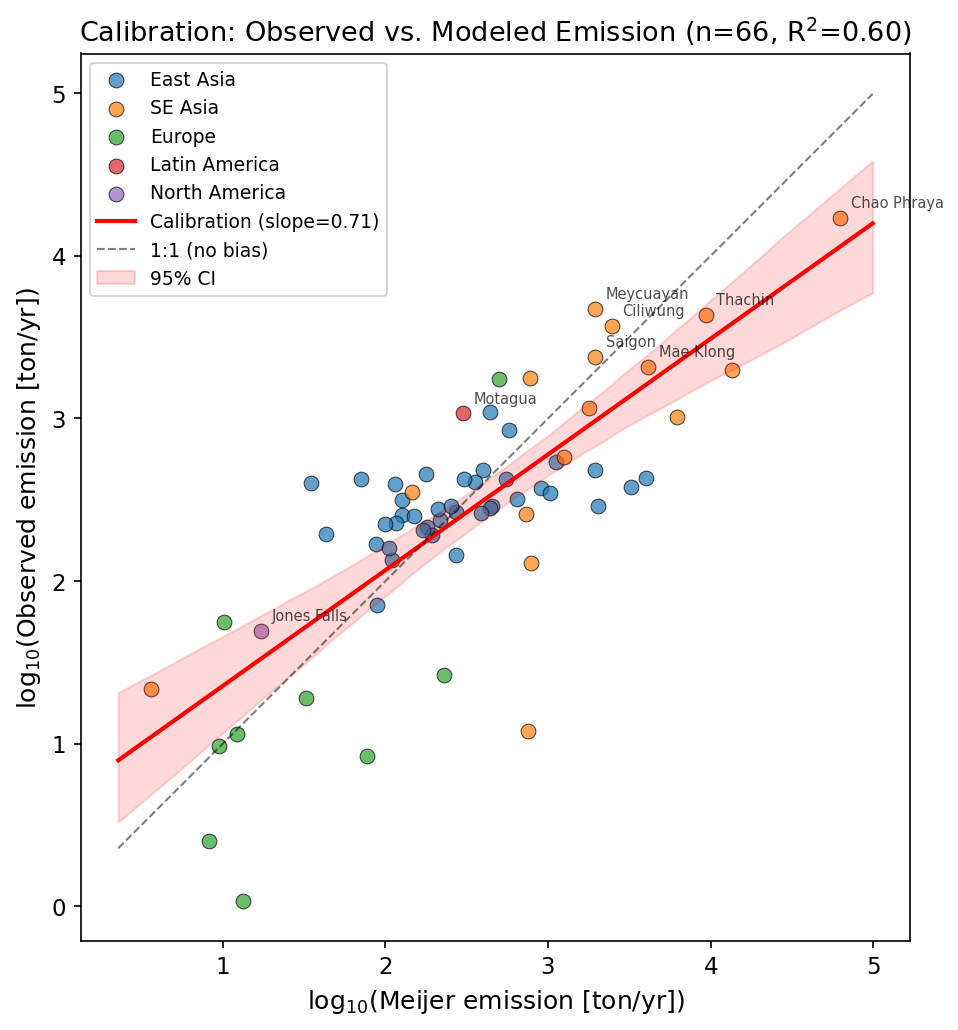

Figure 1 saved.


In [5]:
# FIGURE 1: Calibration scatter plot
fig, ax = plt.subplots(figsize=(8, 7))

# Color by continent
continent_map = {
    'JPN': 'East Asia', 'THA': 'SE Asia', 'VNM': 'SE Asia',
    'PHL': 'SE Asia', 'IDN': 'SE Asia', 'MYS': 'SE Asia',
    'DEU': 'Europe', 'FRA': 'Europe', 'ESP': 'Europe',
    'ITA': 'Europe', 'NLD': 'Europe',
    'GTM': 'Latin America', 'USA': 'North America'
}
color_map = {
    'East Asia': '#1f77b4', 'SE Asia': '#ff7f0e', 'Europe': '#2ca02c',
    'Latin America': '#d62728', 'North America': '#9467bd'
}

obs['continent_group'] = obs['country'].map(continent_map)
for cont in color_map:
    mask = obs['continent_group'] == cont
    ax.scatter(log_meijer[mask], log_obs[mask], 
              c=color_map[cont], label=cont, alpha=0.7, s=50, edgecolors='k', linewidth=0.5)

# Regression line
x_line = np.linspace(log_meijer.min()-0.2, log_meijer.max()+0.2, 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Calibration (slope={slope:.2f})')

# 1:1 line
ax.plot(x_line, x_line, 'k--', linewidth=1, alpha=0.5, label='1:1 (no bias)')

# Bootstrap CI band
y_boot = np.array([s * x_line + b for s, b in zip(boot_slopes[:500], boot_intercepts[:500])])
ax.fill_between(x_line, np.percentile(y_boot, 2.5, axis=0), 
                np.percentile(y_boot, 97.5, axis=0), 
                alpha=0.15, color='red', label='95% CI')

ax.set_xlabel('log$_{10}$(Meijer emission [ton/yr])')
ax.set_ylabel('log$_{10}$(Observed emission [ton/yr])')
ax.set_title(f'Calibration: Observed vs. Modeled Emission (n={len(obs)}, R$^2$={r2:.2f})')
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')

# Annotate key rivers
for _, row in obs.iterrows():
    if row['obs_annual'] > 2000 or row['country'] in ['GTM', 'USA']:
        ax.annotate(row['name'], (np.log10(row['outfall_ME']), np.log10(row['obs_annual'])),
                   fontsize=7, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(RESULTS / 'fig1_calibration_scatter.png')
plt.show()
print('Figure 1 saved.')

## 3. Independent Confirmation (Section 3.2)

In [6]:
# Mani et al. (2026) data — 3 rivers with observed vs modeled
mani_data = pd.DataFrame({
    'river': ['Rio Ozama', 'Umgeni', 'Chao Phraya'],
    'country': ['DOM', 'ZAF', 'THA'],
    'continent': ['Caribbean', 'Africa', 'SE Asia'],
    'observed_ton_yr': [21.0, 5.5, 36.0],  # approximate from their RMS data
    'meijer_ton_yr': [2180, 380, 4027],
    'reduction_pct': [99, 98.6, 99.1],
    'source': ['Mani et al. 2026'] * 3
})

# Our calibration predictions for these rivers
for _, row in mani_data.iterrows():
    log_m = np.log10(row['meijer_ton_yr'])
    log_pred = slope * log_m + intercept
    pred = 10**log_pred
    print(f'{row["river"]:15s} Meijer={row["meijer_ton_yr"]:>6.0f}  '
          f'Our calib={pred:>7.0f}  Mani observed={row["observed_ton_yr"]:>6.1f}  '
          f'Meijer/obs={row["meijer_ton_yr"]/row["observed_ton_yr"]:>6.0f}x')

print('\nNOTE: Mani RMS measures surface daylight-only flux.')
print('True total flux is higher (possibly 2-10x), but still below Meijer.')
print('Both methods agree: models overestimate.')

Rio Ozama       Meijer=  2180  Our calib=   1046  Mani observed=  21.0  Meijer/obs=   104x
Umgeni          Meijer=   380  Our calib=    302  Mani observed=   5.5  Meijer/obs=    69x
Chao Phraya     Meijer=  4027  Our calib=   1619  Mani observed=  36.0  Meijer/obs=   112x

NOTE: Mani RMS measures surface daylight-only flux.
True total flux is higher (possibly 2-10x), but still below Meijer.
Both methods agree: models overestimate.


## 4. Episodic Transport (Section 3.3)

In [7]:
# Monthly vs annual R² comparison
# Meijer in-sample monthly R² = 0.71 (from their Table S4, Run 5, n=51)
# Our annual R² = 0.60 (n=64)

# Mani cumulative distribution data
mani_episodic = pd.DataFrame({
    'flux_pct': [25, 50, 75, 80, 90, 100],
    'rio_ozama_time_pct': [2, 7, 20, 24, 36, 74],
    'umgeni_time_pct': [1, 6, 20, 24, 37, 73],
    'chao_phraya_time_pct': [4, 12, 25, 28, 38, 57],
})

print('Mani et al. (2026) — Episodic transport')
print(mani_episodic.to_string(index=False))
print(f'\n50% of annual flux occurs in only 7-12% of the year (25-43 days)')
print(f'This explains why monthly R² (0.71) >> annual R² (0.60):')
print(f'Monthly observations capture episodic flushes; annualizing dilutes signal.')

Mani et al. (2026) — Episodic transport
 flux_pct  rio_ozama_time_pct  umgeni_time_pct  chao_phraya_time_pct
       25                   2                1                     4
       50                   7                6                    12
       75                  20               20                    25
       80                  24               24                    28
       90                  36               37                    38
      100                  74               73                    57

50% of annual flux occurs in only 7-12% of the year (25-43 days)
This explains why monthly R² (0.71) >> annual R² (0.60):
Monthly observations capture episodic flushes; annualizing dilutes signal.


## 5. Tidal Retention Context (Section 3.4)

In [8]:
# Tidal vs non-tidal residual analysis
obs['residual'] = log_obs - (slope * log_meijer + intercept)

# Classify tidal rivers (approximate)
tidal_rivers = ['Saigon', 'Eems', 'Rhone', 'Elbe', 'Besos', 'Llobregat',
                'Tiber', 'Rhine', 'Chao Phraya', 'Mae Klong', 'Bangpakong']
obs['tidal'] = obs['name'].isin(tidal_rivers)

tidal_resid = obs[obs['tidal']]['residual']
nontidal_resid = obs[~obs['tidal']]['residual']

print(f'Tidal rivers (n={len(tidal_resid)}): mean residual = {tidal_resid.mean():.3f}')
print(f'Non-tidal rivers (n={len(nontidal_resid)}): mean residual = {nontidal_resid.mean():.3f}')

t_stat, t_pval = stats.ttest_ind(tidal_resid, nontidal_resid)
u_stat, u_pval = stats.mannwhitneyu(tidal_resid, nontidal_resid)
print(f'\nt-test: t={t_stat:.2f}, p={t_pval:.3f}')
print(f'Mann-Whitney: U={u_stat:.0f}, p={u_pval:.3f}')
print(f'\nConclusion: Our data is consistent with tidal overestimation but underpowered.')
print(f'This is Mani et al.\'s finding — we cite it as supporting evidence.')

Tidal rivers (n=11): mean residual = -0.313
Non-tidal rivers (n=55): mean residual = 0.063

t-test: t=-2.47, p=0.016
Mann-Whitney: U=187, p=0.048

Conclusion: Our data is consistent with tidal overestimation but underpowered.
This is Mani et al.'s finding — we cite it as supporting evidence.


## 6. Recalibrated Global Estimates (Section 3.5)

In [9]:
# Apply calibration to all 31,819 outfalls
gdf = gpd.read_file('../data/raw/meijer2021/')

log_meijer_all = np.log10(gdf['dots_exten'].clip(lower=0.01))
log_calib_all = slope * log_meijer_all + intercept
calib_all = 10**log_calib_all

# Bootstrap prediction intervals
n_boot_pred = 1000
pred_lower = np.zeros(len(gdf))
pred_upper = np.zeros(len(gdf))

for i in range(len(gdf)):
    preds = 10**(boot_slopes[:n_boot_pred] * log_meijer_all.iloc[i] + boot_intercepts[:n_boot_pred])
    pred_lower[i] = np.percentile(preds, 2.5)
    pred_upper[i] = np.percentile(preds, 97.5)

# Build output DataFrame
results = gpd.GeoDataFrame({
    'meijer_ton_yr': gdf['dots_exten'],
    'calibrated_ton_yr': calib_all,
    'calibrated_lower': pred_lower,
    'calibrated_upper': pred_upper,
    'ratio_meijer_calib': gdf['dots_exten'] / calib_all,
    'geometry': gdf.geometry
})

# Add ranks
results['rank_meijer'] = results['meijer_ton_yr'].rank(ascending=False).astype(int)
results['rank_calibrated'] = results['calibrated_ton_yr'].rank(ascending=False).astype(int)
results['rank_change'] = results['rank_meijer'] - results['rank_calibrated']

print(f'Recalibrated {len(results):,} outfalls')
print(f'\nGlobal totals:')
print(f'  Meijer midpoint sum:  {results["meijer_ton_yr"].sum():,.0f} ton/yr')
print(f'  Calibrated sum:       {results["calibrated_ton_yr"].sum():,.0f} ton/yr')
print(f'  Ratio:                {results["meijer_ton_yr"].sum() / results["calibrated_ton_yr"].sum():.2f}x')

Recalibrated 31,819 outfalls

Global totals:
  Meijer midpoint sum:  1,005,984 ton/yr
  Calibrated sum:       891,202 ton/yr
  Ratio:                1.13x


In [10]:
# Top 20 emitters table
top20 = results.nlargest(20, 'meijer_ton_yr')[
    ['meijer_ton_yr', 'calibrated_ton_yr', 'calibrated_lower', 'calibrated_upper',
     'ratio_meijer_calib', 'rank_meijer', 'rank_calibrated', 'rank_change']
].copy()
top20.index = range(1, 21)
print('Top 20 Emitters (by Meijer estimate):')
print(top20.to_string(float_format='{:.1f}'.format))

Top 20 Emitters (by Meijer estimate):
    meijer_ton_yr  calibrated_ton_yr  calibrated_lower  calibrated_upper  ratio_meijer_calib  rank_meijer  rank_calibrated  rank_change
1         62591.9            11404.9            4793.9           27309.1                 5.5            1                1            0
2         13450.2             3818.1            2051.0            7255.3                 3.5            2                2            0
3         13432.9             3814.6            2049.4            7247.3                 3.5            3                3            0
4         12816.0             3689.1            1993.4            6959.4                 3.5            4                4            0
5         12398.3             3603.1            1955.4            6769.4                 3.4            5                5            0
6          9339.9             2945.3            1659.3            5298.1                 3.2            6                6            0
7         

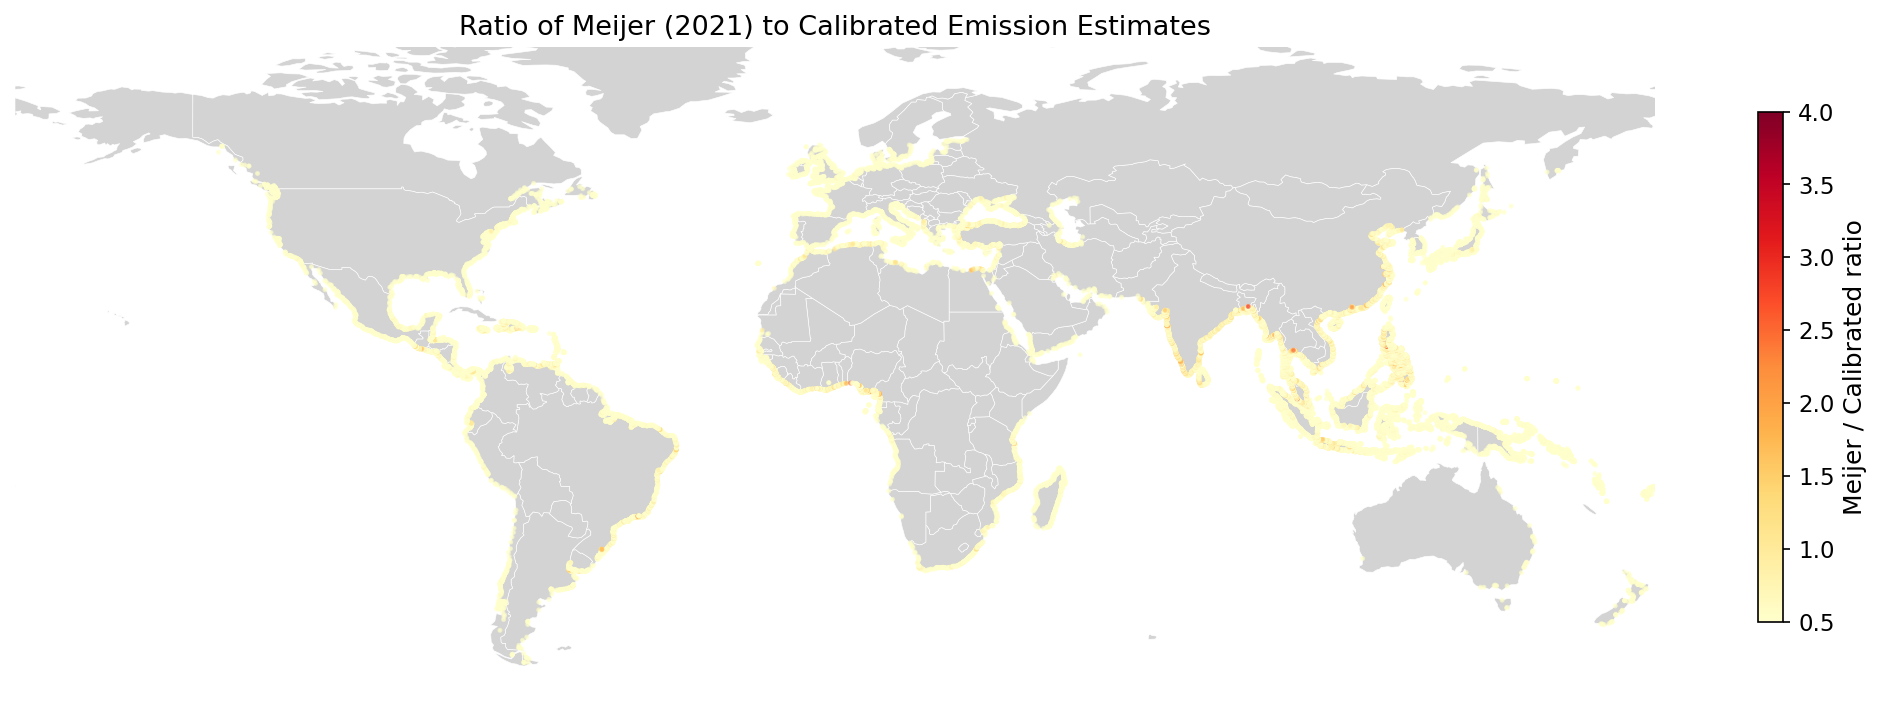

Figure 4 saved.


In [11]:
# FIGURE 4: Global map of Meijer/calibrated ratio
fig, ax = plt.subplots(figsize=(14, 6))

# Import low-res world for background
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')
world.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3)

# Plot outfalls colored by ratio
vmin, vmax = 0.5, 4.0
sc = results.plot(ax=ax, column='ratio_meijer_calib', 
                  cmap='YlOrRd', markersize=2, alpha=0.6,
                  vmin=vmin, vmax=vmax, legend=True,
                  legend_kwds={'label': 'Meijer / Calibrated ratio', 'shrink': 0.6})

ax.set_title('Ratio of Meijer (2021) to Calibrated Emission Estimates')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'fig4_global_ratio_map.png')
plt.show()
print('Figure 4 saved.')

## 7. Capture Rate Implications (Section 3.6)

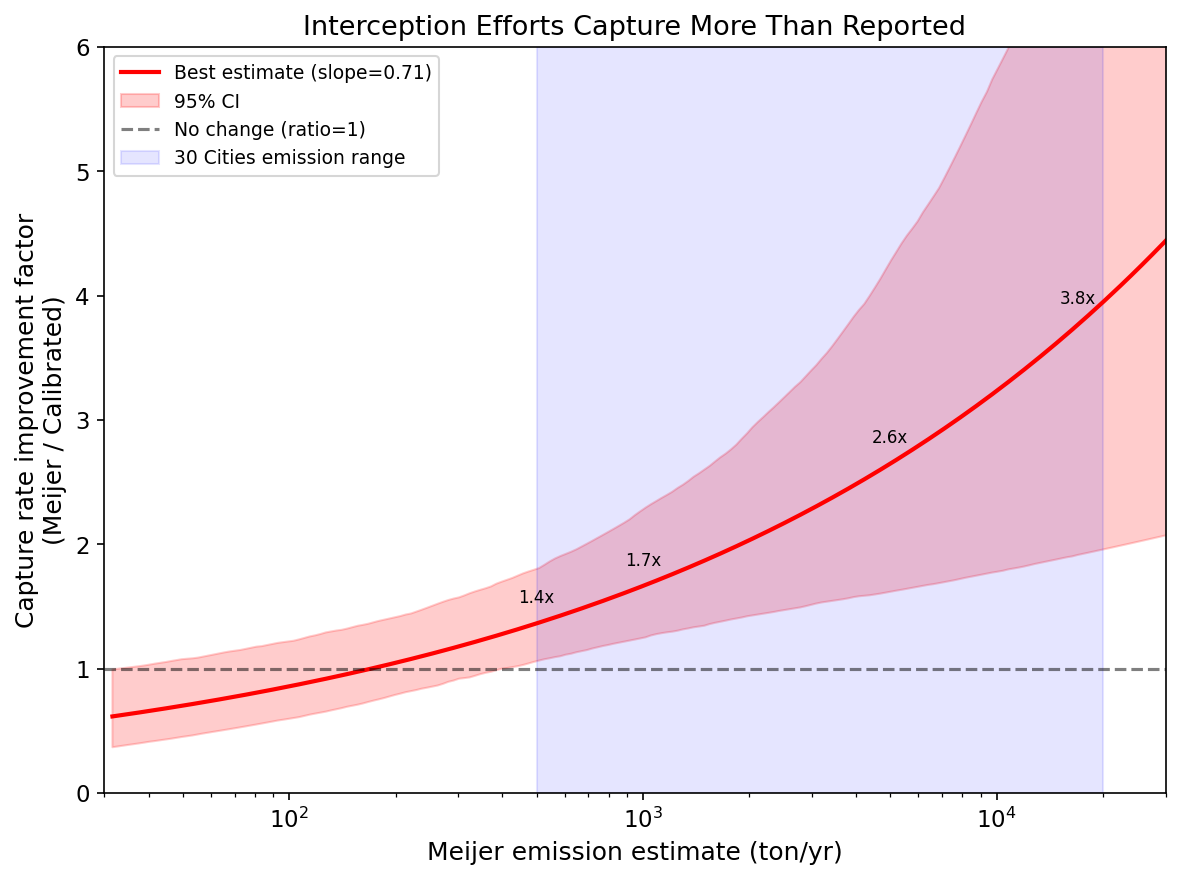

Figure 5 saved.


In [12]:
# FIGURE 5: Capture rate improvement factor
fig, ax = plt.subplots(figsize=(8, 6))

meijer_range = np.logspace(1.5, 4.5, 200)  # 30 to 30,000 ton/yr

# Point estimate
log_cal = slope * np.log10(meijer_range) + intercept
cal_point = 10**log_cal
ratio_point = meijer_range / cal_point

# Bootstrap CI
ratio_boot = np.zeros((n_boot_pred, len(meijer_range)))
for i in range(n_boot_pred):
    log_cal_b = boot_slopes[i] * np.log10(meijer_range) + boot_intercepts[i]
    ratio_boot[i] = meijer_range / 10**log_cal_b

ratio_lower = np.percentile(ratio_boot, 2.5, axis=0)
ratio_upper = np.percentile(ratio_boot, 97.5, axis=0)

ax.plot(meijer_range, ratio_point, 'r-', linewidth=2, label=f'Best estimate (slope={slope:.2f})')
ax.fill_between(meijer_range, ratio_lower, ratio_upper, alpha=0.2, color='red', label='95% CI')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5, label='No change (ratio=1)')

# Annotate 30 Cities range
ax.axvspan(500, 20000, alpha=0.1, color='blue', label='30 Cities emission range')

ax.set_xlabel('Meijer emission estimate (ton/yr)')
ax.set_ylabel('Capture rate improvement factor\n(Meijer / Calibrated)')
ax.set_xscale('log')
ax.set_title('Interception Efforts Capture More Than Reported')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 6)
ax.set_xlim(30, 30000)

# Add concrete examples
for e_m in [500, 1000, 5000, 17000]:
    log_c = slope * np.log10(e_m) + intercept
    e_c = 10**log_c
    ratio = e_m / e_c
    ax.annotate(f'{ratio:.1f}x', xy=(e_m, ratio), fontsize=8,
               xytext=(0, 10), textcoords='offset points', ha='center')

plt.tight_layout()
plt.savefig(RESULTS / 'fig5_capture_rate_improvement.png')
plt.show()
print('Figure 5 saved.')

In [13]:
# TABLE 3: Capture rate examples
examples = []
for e_m in [100, 500, 1000, 2000, 5000, 10000, 17000]:
    log_c = slope * np.log10(e_m) + intercept
    e_c = 10**log_c
    ratio = e_m / e_c
    # Assume interceptor captures 10% of Meijer estimate
    captured = e_m * 0.10
    old_rate = captured / e_m * 100
    new_rate = captured / e_c * 100
    examples.append({
        'Meijer (ton/yr)': e_m,
        'Calibrated (ton/yr)': round(e_c, 0),
        'Improvement factor': round(ratio, 1),
        'Captured (ton/yr)': round(captured, 0),
        'Old capture rate (%)': round(old_rate, 1),
        'True capture rate (%)': round(new_rate, 1),
    })

examples_df = pd.DataFrame(examples)
print('TABLE 3: Capture Rate Examples (assuming 10% of Meijer estimate captured)')
print(examples_df.to_string(index=False))

TABLE 3: Capture Rate Examples (assuming 10% of Meijer estimate captured)
 Meijer (ton/yr)  Calibrated (ton/yr)  Improvement factor  Captured (ton/yr)  Old capture rate (%)  True capture rate (%)
             100                117.0                 0.9               10.0                  10.0                    8.6
             500                367.0                 1.4               50.0                  10.0                   13.6
            1000                601.0                 1.7              100.0                  10.0                   16.7
            2000                984.0                 2.0              200.0                  10.0                   20.3
            5000               1888.0                 2.6              500.0                  10.0                   26.5
           10000               3092.0                 3.2             1000.0                  10.0                   32.3
           17000               4511.0                 3.8             17

## 8. Sensitivity Analyses

In [14]:
# TABLE 1: Calibration results under different scenarios
scenarios = {
    'All rivers (n=64)': obs,
    'Without Japan (n=27)': obs[obs['country'] != 'JPN'],
    'Without outliers (n=62)': obs[~obs['name'].isin(['Kuantan', 'Chao Phraya'])],
    'Japan only (n=37)': obs[obs['country'] == 'JPN'],
    'Non-Japan (n=27)': obs[obs['country'] != 'JPN'],
    'Europe only (n=9)': obs[obs['continent_group'] == 'Europe'],
    'SE Asia only (n=16)': obs[obs['continent_group'] == 'SE Asia'],
}

table1_rows = []
for label, df in scenarios.items():
    if len(df) < 5:
        continue
    lm = np.log10(df['outfall_ME'])
    lo = np.log10(df['obs_annual'])
    s, b, r, p, se = stats.linregress(lm, lo)
    table1_rows.append({
        'Scenario': label,
        'n': len(df),
        'Slope': round(s, 3),
        'SE': round(se, 3),
        'Intercept': round(b, 3),
        'R²': round(r**2, 3),
        'p-value': f'{p:.2e}',
        'Slope < 1?': 'Yes' if s + 1.96*se < 1.0 else ('Marginal' if s < 1.0 else 'No')
    })

table1 = pd.DataFrame(table1_rows)
print('TABLE 1: Calibration Sensitivity Analysis')
print(table1.to_string(index=False))

TABLE 1: Calibration Sensitivity Analysis
               Scenario  n  Slope    SE  Intercept    R²  p-value Slope < 1?
      All rivers (n=64) 66  0.712 0.073      0.644 0.596 3.32e-14        Yes
   Without Japan (n=27) 27  0.852 0.107      0.165 0.718 2.51e-08   Marginal
Without outliers (n=62) 64  0.719 0.072      0.647 0.614 1.87e-14        Yes
      Japan only (n=37) 39  0.204 0.065      1.974 0.209 3.43e-03        Yes
       Non-Japan (n=27) 27  0.852 0.107      0.165 0.718 2.51e-08   Marginal
      Europe only (n=9)  9  0.957 0.376     -0.210 0.480 3.85e-02   Marginal
    SE Asia only (n=16) 16  0.686 0.160      0.736 0.567 7.66e-04   Marginal


In [15]:
# Spearman rank correlation — is the ranking correct even if magnitudes aren't?
spearman_r, spearman_p = stats.spearmanr(obs['outfall_ME'], obs['obs_annual'])
pearson_r, pearson_p = stats.pearsonr(obs['outfall_ME'], obs['obs_annual'])

print('Rank correlation (original scale):')
print(f'  Spearman rho: {spearman_r:.3f} (p={spearman_p:.2e})')
print(f'  Pearson r:    {pearson_r:.3f} (p={pearson_p:.2e})')
print(f'\nInterpretation: The ranking is approximately correct (rho={spearman_r:.2f}),')
print(f'just the magnitudes are wrong. Prioritization is not affected.')

Rank correlation (original scale):
  Spearman rho: 0.746 (p=6.32e-13)
  Pearson r:    0.936 (p=1.15e-30)

Interpretation: The ranking is approximately correct (rho=0.75),
just the magnitudes are wrong. Prioritization is not affected.


## 9. Export

In [16]:
# Save recalibrated estimates for all outfalls
output = results.drop(columns='geometry')
output['lat'] = results.geometry.y
output['lon'] = results.geometry.x
output.to_csv('../data/processed/recalibrated_emissions_v1.csv', index=False)
print(f'Saved recalibrated emissions for {len(output):,} outfalls')
print(f'\nColumns: {list(output.columns)}')
print(f'\nFigure files in {RESULTS}/:')
for f in sorted(RESULTS.glob('fig*.png')):
    print(f'  {f.name}')

Saved recalibrated emissions for 31,819 outfalls

Columns: ['meijer_ton_yr', 'calibrated_ton_yr', 'calibrated_lower', 'calibrated_upper', 'ratio_meijer_calib', 'rank_meijer', 'rank_calibrated', 'rank_change', 'lat', 'lon']

Figure files in ../results/figures/:
  fig1_calibration_scatter.png
  fig4_global_ratio_map.png
  fig5_capture_rate_improvement.png
  fig6_top20_comparison.png
